## Varroa Infestation Prediction - Model Fitter

#### Authors: Evan Kennedy, Mit Ghandi, Anbuchelvan Kumaravel

**Library Imports**

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
from clearml import Task
import time
import json

**Reading In Parameters (Model Name)**

In [12]:
#Opening the JSON config file
with open("../configs/model_config.json", "r") as f:
    config = json.load(f)

#Grabbing Values
model_name = config["model_name"]

**Initializing a ClearML Task**

In [ ]:
# Initialize the ClearML task
task = Task.init(
    project_name="Varroa Infestation Prediction",
    task_name="XGBoost Optuna HPO"
)
logger = task.get_logger()

ClearML Task: created new task id=4ace07075ee84aaa86ea01399e779a0d


Could not fetch GPU stats: NVML Shared Library Not Found


ClearML results page: https://app.clear.ml/projects/ec82bc7c7de54e1bbd3e93c1e3e68734/experiments/4ace07075ee84aaa86ea01399e779a0d/output/log


Importing Processed Data

In [14]:
#Grabbing dataframe from processing file
combined_binary = pd.read_csv('outputs/processed_varroa_data.csv')

**Modelling**

Train-Validation-Test Split (60%, 20%, 20%)

In [15]:
#Note: Stratifying these splits by month to ensure roughly even distribution of seasonsality

#X and Y split
y_bin = combined_binary['infested']
X_bin = combined_binary.drop(columns=['sampling_id', 'infested', 'yard_id', 'hive_id', 'station_id'])

#Train-Validation-Test Split
from sklearn.model_selection import train_test_split

#Splitting off Test Set (20%)
X_bin_temp, X_bin_test, y_bin_temp, y_bin_test = train_test_split(
    X_bin, y_bin, test_size=0.2, stratify=X_bin['obs_month'], random_state=37
)

#Splitting remaining into Train and Validation Sets (60% & 20%)
X_bin_train, X_bin_val, y_bin_train, y_bin_val = train_test_split(
    X_bin_temp, y_bin_temp, test_size=0.25, stratify=X_bin_temp['obs_month'], random_state=37
)

Ensemble Regression (ie. Gradient Boosting w/ many Regression Trees)

In [16]:
#Optimizing hyperparameters, focusing on maximizing ROC-AUC
import optuna
from sklearn.metrics import log_loss, roc_auc_score
from optuna.samplers import TPESampler

#Getting Start Time
start_time = time.time()

#Running optimization
def objective(trial):
    params = {
        "max_depth":        trial.suggest_int("max_depth", 3, 15),
        "learning_rate":    trial.suggest_float("learning_rate", 0.001, 0.3),
        "n_estimators":     trial.suggest_int("n_estimators", 100, 500),
        "subsample":        trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_alpha":        trial.suggest_float("reg_alpha", 0.0, 5.0),
        "reg_lambda":       trial.suggest_float("reg_lambda", 0.0, 5.0),
        "gamma":            trial.suggest_float("gamma", 0.0, 2.0),
    }

    model = xgb.XGBClassifier(
        objective="binary:logistic",
        eval_metric="auc",
        early_stopping_rounds=50,
        random_state=37,
        nthread=1,
        tree_method='exact',
        **params
    )
    model.fit(
        X_bin_train, y_bin_train,
        eval_set=[(X_bin_val, y_bin_val)],
        verbose=False
    )

    preds = model.predict_proba(X_bin_val)[:, 1]
    auc = roc_auc_score(y_bin_val, preds)
    logloss = log_loss(y_bin_val, preds)

    #Log per-trial metrics to ClearML
    logger.report_scalar("val_auc", "Training AUC-ROC", value=auc, iteration=trial.number)
    logger.report_scalar("val_logloss", "Training Logloss", value=logloss, iteration=trial.number)
    
    #Logging Training Time to ClearML
    training_time = time.time() - start_time
    logger.report_scalar(
        title="Performance",
        series="Training Time (s)",
        value=training_time,
        iteration=trial.number
    )
    
    return auc

study = optuna.create_study(direction="maximize", sampler=TPESampler(seed=37))
study.optimize(objective, n_trials=50)

# Best results
print("Best AUC-ROC:", study.best_value)
print("Best params:", study.best_params)

[I 2026-05-03 22:54:33,576] A new study created in memory with name: no-name-aca8ab10-02ee-431d-be81-931453a7f8c9
[I 2026-05-03 22:54:35,030] Trial 0 finished with value: 0.9571338893372792 and parameters: {'max_depth': 15, 'learning_rate': 0.13976535411701788, 'n_estimators': 177, 'subsample': 0.7909474384399959, 'colsample_bytree': 0.8100421050868136, 'reg_alpha': 3.4211200873158703, 'reg_lambda': 0.5171877750999904, 'gamma': 1.490951532568867}. Best is trial 0 with value: 0.9571338893372792.


ClearML Monitor: GPU monitoring failed getting GPU reading, switching off GPU monitoring


[I 2026-05-03 22:54:37,234] Trial 1 finished with value: 0.9645099094251637 and parameters: {'max_depth': 6, 'learning_rate': 0.22627395155614066, 'n_estimators': 417, 'subsample': 0.8137002981396799, 'colsample_bytree': 0.7217444218892007, 'reg_alpha': 4.817326762037329, 'reg_lambda': 4.485332768597761, 'gamma': 0.39360857615704825}. Best is trial 1 with value: 0.9645099094251637.
[I 2026-05-03 22:54:39,364] Trial 2 finished with value: 0.9724912563895615 and parameters: {'max_depth': 10, 'learning_rate': 0.17243970669882297, 'n_estimators': 382, 'subsample': 0.9646310092004129, 'colsample_bytree': 0.5256149144438098, 'reg_alpha': 0.6740599445713391, 'reg_lambda': 0.5851425305822705, 'gamma': 0.7294495214011822}. Best is trial 2 with value: 0.9724912563895615.
[I 2026-05-03 22:54:41,180] Trial 3 finished with value: 0.9692404268675455 and parameters: {'max_depth': 13, 'learning_rate': 0.2911025735372444, 'n_estimators': 233, 'subsample': 0.7392099370802507, 'colsample_bytree': 0.58946

Best AUC-ROC: 0.9786117836965295
Best params: {'max_depth': 6, 'learning_rate': 0.20095362060401456, 'n_estimators': 333, 'subsample': 0.6412978750911235, 'colsample_bytree': 0.5474250800666617, 'reg_alpha': 0.4639361642318713, 'reg_lambda': 0.13399310747674265, 'gamma': 0.4603674287288465}


In [17]:
#Using optimized hyperparameters
best_model = xgb.XGBClassifier(
    objective="binary:logistic",
    eval_metric="auc",
    early_stopping_rounds=50,
    random_state=37,
    **study.best_params
)
best_model.fit(
    X_bin_train, y_bin_train,
    eval_set=[(X_bin_val, y_bin_val)],
    verbose=False
)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.5474250800666617
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",50
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import lo

Classification Performance

In [18]:
from sklearn.metrics import accuracy_score, log_loss

#Predicted class labels
y_bin_test_pred = best_model.predict(X_bin_test)

#Predicted probabilities
y_bin_test_prob = best_model.predict_proba(X_bin_test)

#Accuracy
accuracy = accuracy_score(y_bin_test, y_bin_test_pred)

#Log loss (binary or multiclass-safe)
loss = log_loss(y_bin_test, y_bin_test_prob)

print("Accuracy:", accuracy)
print("Log Loss:", loss)

Accuracy: 0.9564459930313589
Log Loss: 0.14462220777504714


ROC-AUC Score: 0.9183


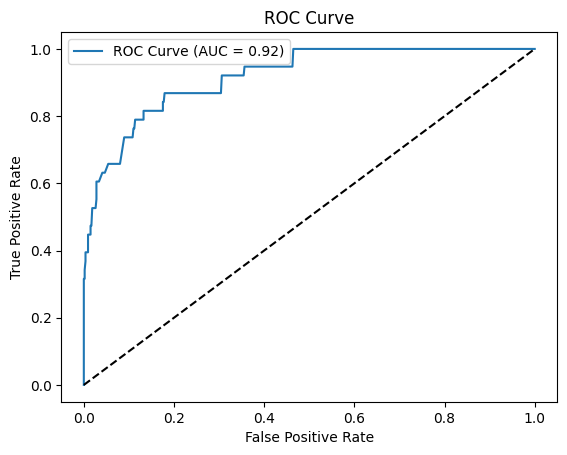

In [19]:
from sklearn.metrics import roc_curve, roc_auc_score

#ROC-AUC Score
y_bin_test_probs = best_model.predict_proba(X_bin_test)[:, 1]
auc = roc_auc_score(y_bin_test, y_bin_test_probs)
print(f"ROC-AUC Score: {auc:.4f}")

#ROC Curve
fpr, tpr, thresholds = roc_curve(y_bin_test, y_bin_test_probs)
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {auc:.2f})')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()

#Random guessing diagonal for visual comparison
plt.plot([0, 1], [0, 1], 'k--')
plt.show()

Logging to ClearML

In [20]:
# Log best hyperparameters
task.connect(study.best_params)

# Log final test metrics
logger = task.get_logger()
logger.report_scalar("test_accuracy", "final_test_accuracy", value=accuracy, iteration=0)
logger.report_scalar("test_log_loss", "final_test_log_loss", value=loss, iteration=0)
logger.report_scalar("test_auc", "final_test_auc", value=auc, iteration=0)

# Log the ROC curve plot
logger.report_matplotlib_figure(
    title="ROC Curve",
    series="test",
    figure=plt.gcf(),   # call this right after plt.show()
    iteration=0
)

# Upload the saved model as an artifact
task.upload_artifact("varroa_predictor", artifact_object="varroa_predictor.json")

# Mark task complete
task.close()

<Figure size 640x480 with 0 Axes>

Exporting Model

In [21]:
#Saving model
best_model.save_model('outputs/' + model_name)